In [13]:
import pandas as pd 
import pandas_ta as ta

In [332]:
asset = 'bitcoin'
volume_data = pd.read_csv(f'/Users/valter.rebelo/MissionControl/data/micro/assetData/{asset}.csv')[['date', 'total_volume']]
volume_data.set_index('date', inplace=True)
volume_data.dropna(inplace=True)
data = pd.read_csv(f'/Users/valter.rebelo/MissionControl/data/micro/candleData/{asset}_candles.csv')
data.set_index('date', inplace=True)
data.dropna(inplace=True)
data = data.join(volume_data, how='left')
data
data = data.loc['2022-12-1':'2025-05-01']

# Calculate the mean of OHLC
data['ohlc_mean'] = (data['open'] + data['high'] + data['low'] + data['close']) / 4

# Fix the RSI calculation - correct syntax for pandas_ta.rsi
data['rsi_close'] = ta.rsi(data['close'], length=28)
data['rsi_high'] = ta.rsi(data['high'], length=28)
data['rsi_low'] = ta.rsi(data['low'], length=28)
data['rsi_open'] = ta.rsi(data['open'], length=28)
# Calculate the average of the four RSI values
data['rsi_smooth'] = (data['rsi_close'] + data['rsi_high'] + data['rsi_low'] + data['rsi_open']) / 4

data['close_roc'] = ta.roc(data['close'], length=28)  # Using ta.roc instead of pct_change
data['high_roc'] = ta.roc(data['high'], length=28)
data['low_roc'] = ta.roc(data['low'], length=28)
data['open_roc'] = ta.roc(data['open'], length=28)
data['smooth_roc'] = (data['close_roc'] + data['high_roc'] + data['low_roc'] + data['open_roc']) / 4

# Create RSI momentum indicator based on rules from the PineScript
data['rsi_momentum'] = 0  # Initialize with default value of 0

# Initialize a variable to track the last active mode
last_active_mode = 0

# Process each row to determine rsi_momentum with memory of last active mode
for idx in data.index:
    # Bullish condition: RSI smooth > 50 AND smooth ROC > 0
    if data.loc[idx, 'rsi_smooth'] > 50 and data.loc[idx, 'smooth_roc'] > 0:
        data.loc[idx, 'rsi_momentum'] = 1
        last_active_mode = 1
    # Bearish condition: RSI smooth < 50 AND smooth ROC < 0
    elif data.loc[idx, 'rsi_smooth'] < 50 and data.loc[idx, 'smooth_roc'] < 0:
        data.loc[idx, 'rsi_momentum'] = 0
        last_active_mode = 0
    # Mixed conditions: keep the last active mode
    else:
        data.loc[idx, 'rsi_momentum'] = last_active_mode

# Calculate forward returns
data['forward_5d_returns'] = data['close'].pct_change(periods=5).shift(-5)
data['forward_10d_returns'] = data['close'].pct_change(periods=10).shift(-10)
data['forward_1m_returns'] = data['close'].pct_change(periods=21).shift(-21)  # Assuming 21 trading days in a month

# Calculate rolling z-score normalized close with 14-day window
rolling_mean = data['close'].rolling(window=14).mean()
rolling_std = data['close'].rolling(window=14).std()
data['z'] = (data['close'] - rolling_mean) / rolling_std

rolling_mean_vol = data['total_volume'].rolling(window=14).mean()
rolling_std_vol = data['total_volume'].rolling(window=14).std()
data['z_vol'] = (data['total_volume'] - rolling_mean_vol) / rolling_std_vol

# Calculate rolling z-score for the OHLC mean with 14-day window
ohlc_rolling_mean = data['ohlc_mean'].rolling(window=14).mean()
ohlc_rolling_std = data['ohlc_mean'].rolling(window=14).std()
data['z_ohlc'] = (data['ohlc_mean'] - ohlc_rolling_mean) / ohlc_rolling_std

# Drop NaN values
data.dropna(inplace=True)


Correlation between forward_10d_returns and rsi_momentum: -0.0010


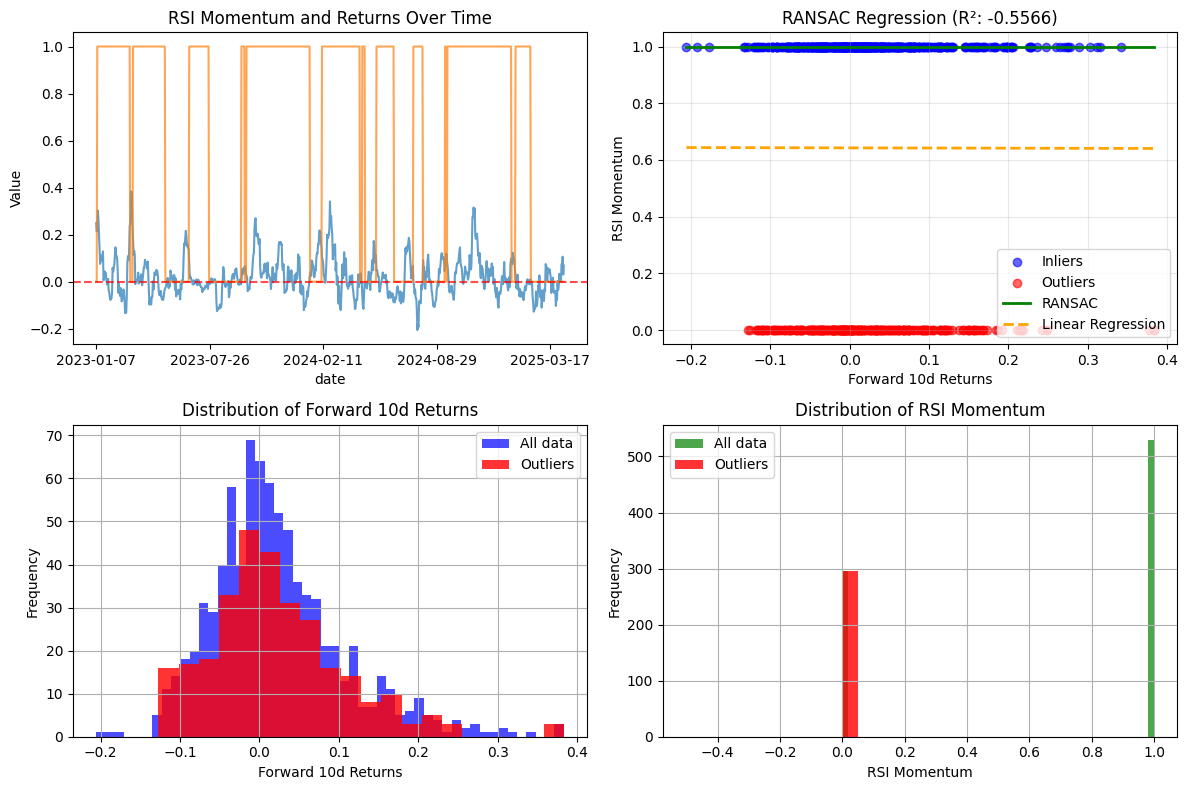

RANSAC R² score: -0.5566
Number of inliers: 530
Number of outliers: 295
Percentage of outliers: 35.76%
RANSAC coefficient: -0.0000
RANSAC intercept: 1.0000


In [336]:
# Calculate correlation between forward_10d_returns and rsi_momentum
correlation = data['forward_10d_returns'].corr(data['rsi_momentum'])
print(f"Correlation between forward_10d_returns and rsi_momentum: {correlation:.4f}")

# RANSAC Regression Analysis
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for RANSAC regression
X = data['forward_10d_returns'].values.reshape(-1, 1)
y = data['rsi_momentum'].values

# Fit RANSAC regression
ransac = RANSACRegressor(LinearRegression(), 
                        residual_threshold=0.5,  # Threshold for outliers
                        random_state=42)
ransac.fit(X, y)

# Get inliers and outliers
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# Predictions
line_X = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
line_y_ransac = ransac.predict(line_X)

# Regular linear regression for comparison
lr = LinearRegression()
lr.fit(X, y)
line_y_lr = lr.predict(line_X)

plt.figure(figsize=(12, 8))

# Plot 1: Time series of both variables
plt.subplot(2, 2, 1)
data['forward_10d_returns'].plot(label='10d Returns', alpha=0.7)
data['rsi_momentum'].plot(label='RSI Momentum', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('RSI Momentum and Returns Over Time')
#plt.legend()
plt.ylabel('Value')

# Plot 2: RANSAC regression scatter plot
plt.subplot(2, 2, 2)
plt.scatter(X[inlier_mask], y[inlier_mask], color='blue', alpha=0.6, label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask], color='red', alpha=0.6, label='Outliers')
plt.plot(line_X, line_y_ransac, color='green', linewidth=2, label='RANSAC')
plt.plot(line_X, line_y_lr, color='orange', linewidth=2, linestyle='--', label='Linear Regression')
plt.xlabel('Forward 10d Returns')
plt.ylabel('RSI Momentum')
plt.title(f'RANSAC Regression (R²: {ransac.score(X, y):.4f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Distribution of forward_10d_returns with outlier highlighting
plt.subplot(2, 2, 3)
data['forward_10d_returns'].hist(bins=50, alpha=0.7, color='blue', label='All data')
data.loc[outlier_mask, 'forward_10d_returns'].hist(bins=20, alpha=0.8, color='red', label='Outliers')
plt.title('Distribution of Forward 10d Returns')
plt.xlabel('Forward 10d Returns')
plt.ylabel('Frequency')
plt.legend()

# Plot 4: Distribution of rsi_momentum with outlier highlighting
plt.subplot(2, 2, 4)
data['rsi_momentum'].hist(bins=50, alpha=0.7, color='green', label='All data')
data.loc[outlier_mask, 'rsi_momentum'].hist(bins=20, alpha=0.8, color='red', label='Outliers')
plt.title('Distribution of RSI Momentum')
plt.xlabel('RSI Momentum')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Print RANSAC results
print(f"RANSAC R² score: {ransac.score(X, y):.4f}")
print(f"Number of inliers: {np.sum(inlier_mask)}")
print(f"Number of outliers: {np.sum(outlier_mask)}")
print(f"Percentage of outliers: {100 * np.sum(outlier_mask) / len(y):.2f}%")
print(f"RANSAC coefficient: {ransac.estimator_.coef_[0]:.4f}")
print(f"RANSAC intercept: {ransac.estimator_.intercept_:.4f}")

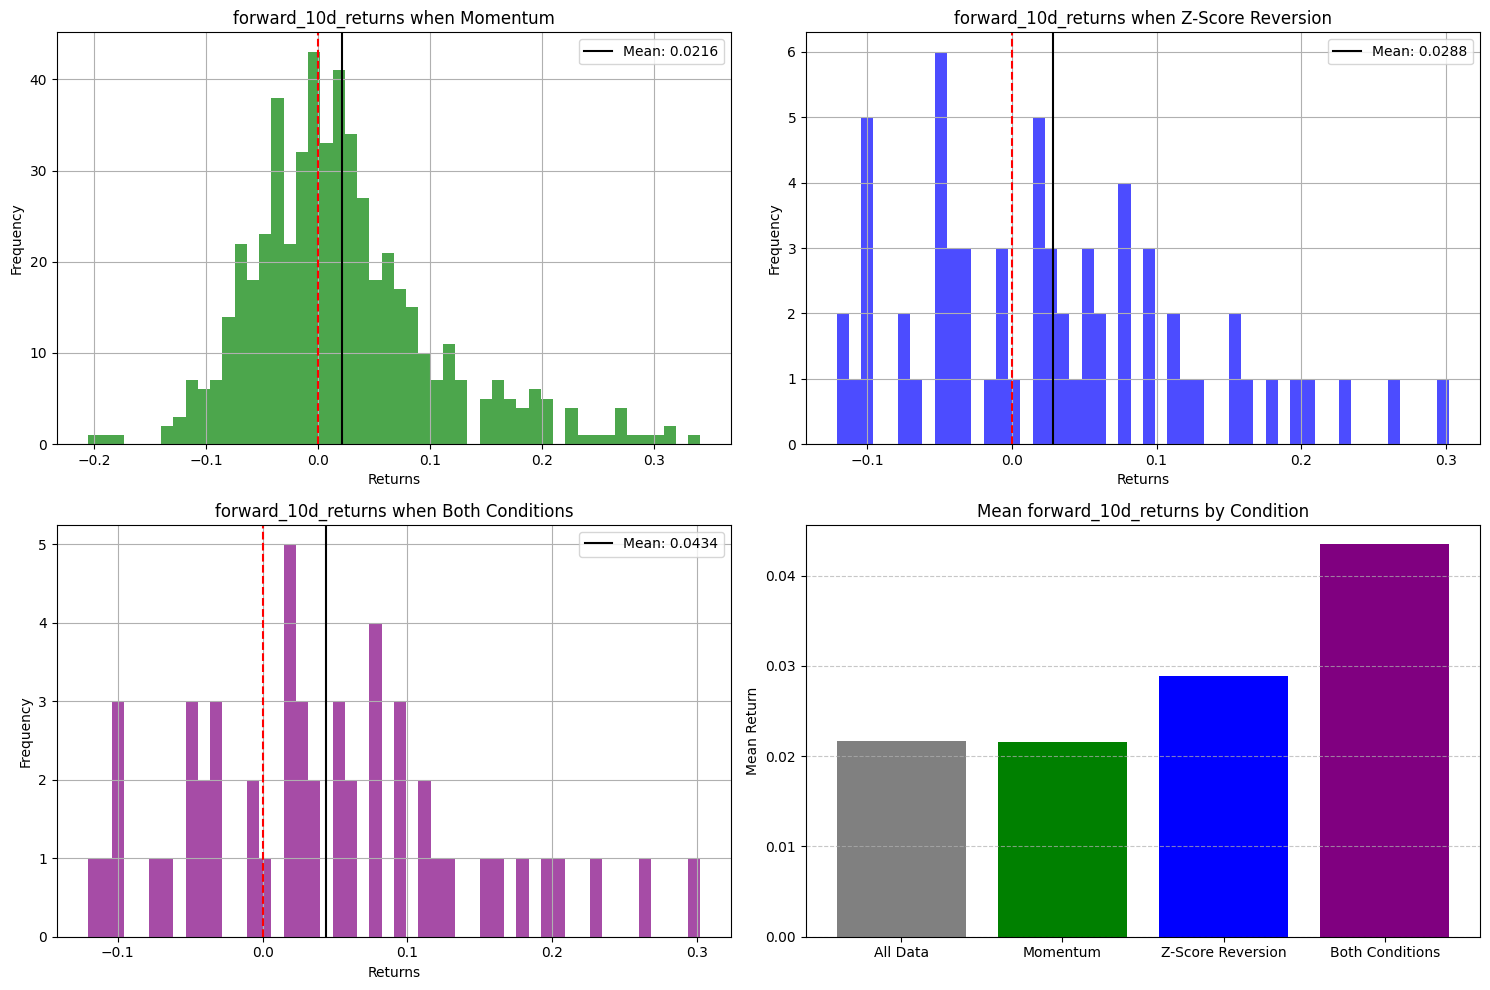


Summary Statistics for forward_10d_returns:
Condition                  Mean     Median        Min        Max       Skew   Kurtosis      Count
-------------------- ---------- ---------- ---------- ---------- ---------- ---------- ----------
All data                 0.0217     0.0088    -0.2056     0.3833     1.0109     1.8026        825
Momentum                 0.0216     0.0102    -0.2056     0.3412     0.9707     1.5754        530
Z-Score Reversion        0.0288     0.0194    -0.1209     0.3022     0.6689     0.1069         64
Both Conditions          0.0434     0.0294    -0.1209     0.3022     0.5646     0.1033         52


In [337]:
import matplotlib.pyplot as plt

# Create a figure with subplots for different conditions
plt.figure(figsize=(15, 10))

# Define the return column to analyze
return_column = 'forward_10d_returns'

# Define conditions with descriptive names
condition1_name = 'Momentum'
condition2_name = 'Z-Score Reversion'
combined_name = 'Both Conditions'

# Define the actual conditions
conditions = {
    condition1_name: data['rsi_momentum'] == 1,
    condition2_name: data['z_ohlc'] >= 2,
    combined_name: (data['rsi_momentum'] == 1) & (data['z_ohlc'] >= 2)
}

# Plot 1: Forward returns for condition 1
plt.subplot(2, 2, 1)
data[conditions[condition1_name]][return_column].hist(bins=50, alpha=0.7, color='green')
plt.title(f'{return_column} when {condition1_name}')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=data[conditions[condition1_name]][return_column].mean(), 
           color='black', linestyle='-', label=f"Mean: {data[conditions[condition1_name]][return_column].mean():.4f}")
plt.legend()

# Plot 2: Forward returns for condition 2
plt.subplot(2, 2, 2)
data[conditions[condition2_name]][return_column].hist(bins=50, alpha=0.7, color='blue')
plt.title(f'{return_column} when {condition2_name}')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=data[conditions[condition2_name]][return_column].mean(), 
           color='black', linestyle='-', label=f"Mean: {data[conditions[condition2_name]][return_column].mean():.4f}")
plt.legend()

# Plot 3: Forward returns when both conditions are met
plt.subplot(2, 2, 3)
data[conditions[combined_name]][return_column].hist(bins=50, alpha=0.7, color='purple')
plt.title(f'{return_column} when {combined_name}')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=data[conditions[combined_name]][return_column].mean(), 
           color='black', linestyle='-', label=f"Mean: {data[conditions[combined_name]][return_column].mean():.4f}")
plt.legend()

# Plot 4: Comparison of means
plt.subplot(2, 2, 4)
condition_labels = ['All Data'] + list(conditions.keys())
means = [
    data[return_column].mean(),
    data[conditions[condition1_name]][return_column].mean(),
    data[conditions[condition2_name]][return_column].mean(),
    data[conditions[combined_name]][return_column].mean()
]
counts = [
    len(data),
    len(data[conditions[condition1_name]]),
    len(data[conditions[condition2_name]]),
    len(data[conditions[combined_name]])
]

plt.bar(condition_labels, means, color=['gray', 'green', 'blue', 'purple'])
plt.title(f'Mean {return_column} by Condition')
plt.ylabel('Mean Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of bars

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics for {return_column}:")
print(f"{'Condition':<20} {'Mean':>10} {'Median':>10} {'Min':>10} {'Max':>10} {'Skew':>10} {'Kurtosis':>10} {'Count':>10}")
print(f"{'-'*20} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
print(f"{'All data':<20} {data[return_column].mean():>10.4f} {data[return_column].median():>10.4f} {data[return_column].min():>10.4f} {data[return_column].max():>10.4f} {data[return_column].skew():>10.4f} {data[return_column].kurtosis():>10.4f} {len(data):>10}")
for condition_name, condition in conditions.items():
    print(f"{condition_name:<20} {data[condition][return_column].mean():>10.4f} {data[condition][return_column].median():>10.4f} {data[condition][return_column].min():>10.4f} {data[condition][return_column].max():>10.4f} {data[condition][return_column].skew():>10.4f} {data[condition][return_column].kurtosis():>10.4f} {len(data[condition]):>10}")


In [286]:
# Plot close prices over time using Plotly
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

fig = go.Figure()

# Add grey line for reference
fig.add_trace(go.Scatter(
    x=data.index,
    y=data['close'],
    mode='lines',
    name='Close Price',
    line=dict(color='grey', width=1)
))

# Create separate traces for green and red dots based on rsi_momentum
green_dots = data[data['rsi_momentum'] == 1]
red_dots = data[data['rsi_momentum'] != 1]

# Add green dots for rsi_momentum = 1
fig.add_trace(go.Scatter(
    x=green_dots.index,
    y=green_dots['close'],
    mode='markers',
    name='RSI Momentum = 1',
    marker=dict(color='green', size=4)
))

# Add red dots for rsi_momentum = 0
fig.add_trace(go.Scatter(
    x=red_dots.index,
    y=red_dots['close'],
    mode='markers',
    name='RSI Momentum = 0',
    marker=dict(color='red', size=4)
))

fig.update_layout(
    title='Close Prices Over Time with RSI Momentum',
    xaxis_title='Date',
    yaxis_title='Close Price',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()
